In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

print(" Librairies importées avec succès")

✅ Librairies importées avec succès


In [ ]:
colonnes = [
    'statut_compte', 'duree_mois', 'historique_credit', 'objet_credit',
    'montant_credit', 'epargne', 'emploi_depuis', 'taux_remboursement',
    'statut_personnel', 'autres_debiteurs', 'residence_depuis',
    'propriete', 'age', 'autres_credits', 'logement',
    'credits_existants', 'emploi', 'personnes_charge',
    'telephone', 'travailleur_etranger', 'risque'
]

df = pd.read_csv('german.data.txt', sep=' ', header=None, names=colonnes)
df['risque'] = df['risque'].map({1: 0, 2: 1})

print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

✅ Dataset chargé : 1000 lignes, 21 colonnes


,statut_compte,duree_mois,historique_credit,objet_credit,montant_credit,epargne,emploi_depuis,taux_remboursement,statut_personnel,autres_debiteurs,...,propriete,age,autres_credits,logement,credits_existants,emploi,personnes_charge,telephone,travailleur_etranger,risque
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


=== DISTRIBUTION DE LA CIBLE ===
0    700
1    300
Name: risque, dtype: int64
Taux de défaut : 30.0%


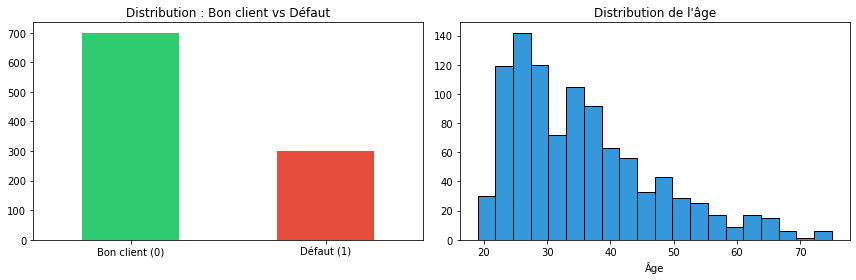

✅ Graphique sauvegardé


In [ ]:
print("=== DISTRIBUTION DE LA CIBLE ===")
print(df['risque'].value_counts())
print(f"Taux de défaut : {df['risque'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['risque'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Distribution : Bon client vs Défaut')
axes[0].set_xticklabels(['Bon client (0)', 'Défaut (1)'], rotation=0)

axes[1].hist(df['age'], bins=20, color='#3498db', edgecolor='black')
axes[1].set_title("Distribution de l'âge")
axes[1].set_xlabel('Âge')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150)
plt.show()
print("Graphique sauvegardé")

In [ ]:
df_encoded = df.copy()
le = LabelEncoder()

colonnes_cat = df.select_dtypes(include='object').columns
for col in colonnes_cat:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop('risque', axis=1)
y = df_encoded['risque']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

✅ Train : 800 lignes | Test : 200 lignes


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print(" Modèle entraîné !")
print(f"\nROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")
print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred, 
      target_names=['Bon client', 'Défaut']))

✅ Modèle entraîné !

ROC-AUC Score : 0.8140

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

  Bon client       0.82      0.89      0.85       140
      Défaut       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



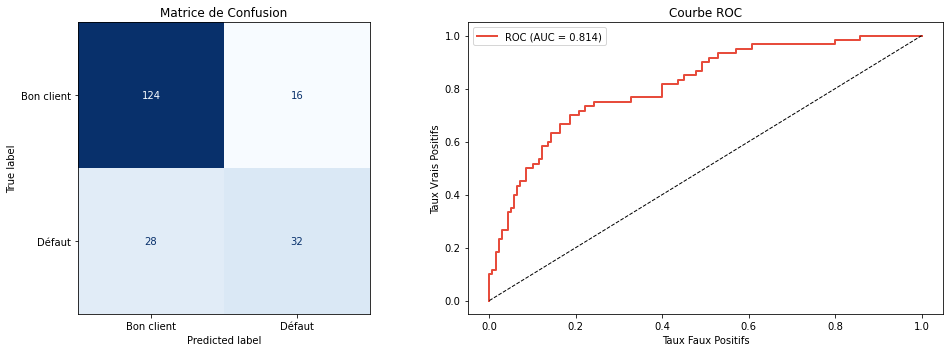

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Bon client', 'Défaut'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de Confusion')

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].set_title('Courbe ROC')
axes[1].legend()

plt.tight_layout()
plt.savefig('resultats_modele.png', dpi=150)
plt.show()

In [ ]:
joblib.dump(rf_model, 'scoring_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

model_test = joblib.load('scoring_model.pkl')
print(" Modèle sauvegardé : scoring_model.pkl")
print(" Scaler sauvegardé : scaler.pkl")
print("\nCes 2 fichiers seront uploadés sur S3 ensuite 🚀")

✅ Modèle sauvegardé : scoring_model.pkl
✅ Scaler sauvegardé : scaler.pkl

Ces 2 fichiers seront uploadés sur S3 ensuite 🚀
